<a href="https://colab.research.google.com/github/dwmhr12/Nike_Run_Club_Tugas/blob/main/05_nike_run_club_reviews_tfidf_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing and importing libraries

In [1]:
pip install -U nltk

In [2]:
pip install tensorflow_hub

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [4]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
stop_words = set(stopwords.words('english'))

# To check is there any GPU available or not




In [7]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")


GPU not available, CPU used


# Load the ike Review dataset for sentiment analysis between positive and negative reviews

In [8]:
df_nike_reviews2 = pd.read_csv('df_nike_reviews2.csv', sep=',', encoding='utf-8', engine='python', on_bad_lines='skip')
print(df_nike_reviews2.shape)


(15733, 15)


In [9]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15733 entries, 0 to 15732
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content                 15733 non-null  object 
 1   score                   15733 non-null  int64  
 2   thumbsUpCount           15733 non-null  int64  
 3   reviewCreatedVersion    15733 non-null  object 
 4   at                      15733 non-null  object 
 5   appVersion              15733 non-null  object 
 6   id                      15733 non-null  int64  
 7   sentiment_polarity      15733 non-null  float64
 8   sentiment_subjectivity  15733 non-null  float64
 9   sentiment_rating        15733 non-null  object 
 10  final_cleaned           15733 non-null  object 
 11  token                   15733 non-null  object 
 12  token_after_sr          15733 non-null  object 
 13  lemmatized_tokens       15733 non-null  object 
 14  cleaned_text            15702 non-null

In [10]:
df_nike_reviews2 = df_nike_reviews2.dropna(subset=['cleaned_text'])

In [11]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15702 entries, 0 to 15732
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content                 15702 non-null  object 
 1   score                   15702 non-null  int64  
 2   thumbsUpCount           15702 non-null  int64  
 3   reviewCreatedVersion    15702 non-null  object 
 4   at                      15702 non-null  object 
 5   appVersion              15702 non-null  object 
 6   id                      15702 non-null  int64  
 7   sentiment_polarity      15702 non-null  float64
 8   sentiment_subjectivity  15702 non-null  float64
 9   sentiment_rating        15702 non-null  object 
 10  final_cleaned           15702 non-null  object 
 11  token                   15702 non-null  object 
 12  token_after_sr          15702 non-null  object 
 13  lemmatized_tokens       15702 non-null  object 
 14  cleaned_text            15702 non-null  obj

In [12]:
# Hapus kolom yang tidak dibutuhkan
df_nike_reviews2 = df_nike_reviews2[['cleaned_text', 'sentiment_rating']]

# Rename kolom sesuai keinginan
df_nike_reviews2 = df_nike_reviews2.rename(columns={'cleaned_text': 'review', 'sentiment_rating': 'sentiment'})

# Cek hasilnya
print(df_nike_reviews2.head())


                                              review sentiment
0            stop recording midway notby waste space  Negative
1                                               best  Positive
2   heart rate monitor notworking galaxy watch ultra  Negative
3  year ago logged old data lost contacted suppor...  Negative
4  need login account morning annoying need login...  Negative


In [13]:
df_nike_reviews2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15702 entries, 0 to 15732
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     15702 non-null  object
 1   sentiment  15702 non-null  object
dtypes: object(2)
memory usage: 368.0+ KB


# Exploratory Data Analysis for IMDB dataset

In [14]:
class EDA():
    def get_length_dist(self,data):
        rev_len = [len(i) for i in data]
        pd.Series(rev_len).hist()
        plt.title('Number of types of commets')
        plt.xlabel('length')
        plt.ylabel('number')
        plt.show()
        print(pd.Series(rev_len).describe())
    def get_class_dist(self,df):
        df['sentiment'].replace({1:'positive',0:'negative'}).value_counts().plot(kind='bar',figsize=(7,4))
        plt.title('Number of types')
        plt.xlabel('Comment_type')
        plt.ylabel('number')
        plt.show()


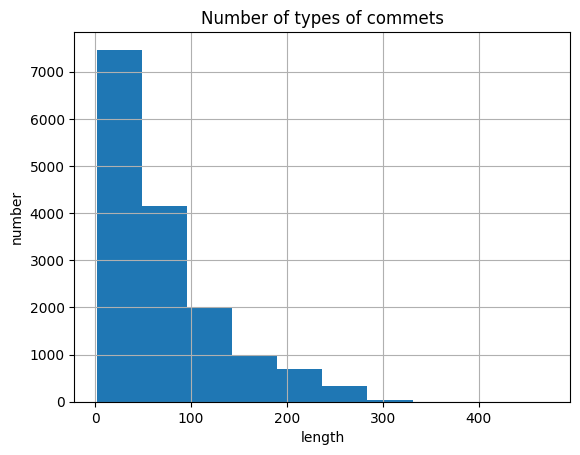

count    15702.000000
mean        70.932875
std         61.417897
min          2.000000
25%         25.000000
50%         52.000000
75%         98.000000
max        472.000000
dtype: float64


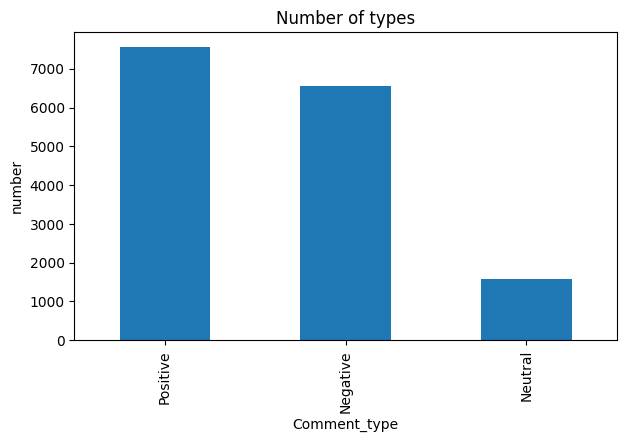

In [15]:
eda = EDA()
eda.get_length_dist(df_nike_reviews2['review'])
eda.get_class_dist(df_nike_reviews2)

# Preprocess the data

In [16]:
def preprocess_text(text):
    # Menghapus tag HTML jika ada
    text = re.sub(r'<[^>]*>', '', text)

    # Menghapus karakter non-alfanumerik dan spasi ekstra
    text = re.sub(r'[^\w\s]', '', text)  # Tetap menyimpan angka (digit)
    text = re.sub(r'\s+', ' ', text).strip()  # Menghapus spasi berlebih

    # Mengubah teks menjadi huruf kecil
    text = text.lower()

    # Tokenisasi dan menghapus stopwords
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]

    # Menggabungkan kembali menjadi string yang bersih
    return ' '.join(words)

In [17]:
import nltk
nltk.download('punkt')       # Resource utama
nltk.download('punkt_tab')   # Jika ternyata diperlukan


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
# Terapkan preprocessing pada kolom 'review'
df_nike_reviews2['review'] = df_nike_reviews2['review'].apply(preprocess_text)


In [19]:
df_nike_reviews2['review'].head(20)


,review
0,stop recording midway notby waste space
1,best
2,heart rate monitor notworking galaxy watch ultra
3,year ago logged old data lost contacted suppor...
4,need login account morning annoying need login...
5,great coaching
6,year however taking long open open landor load...
7,love show progression
8,plan buggy constantly get frozen screen hold c...
9,notcalibrate correctly


# Split x=feature, y=target

In [20]:
x = df_nike_reviews2['review']
y = df_nike_reviews2['sentiment']

In [21]:
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
Y = label_encode.fit_transform(df_nike_reviews2['sentiment'])
Y

array([0, 2, 0, ..., 0, 2, 1])

In [22]:
y

,sentiment
0,Negative
1,Positive
2,Negative
3,Negative
4,Negative
...,...
15728,Positive
15729,Positive
15730,Negative
15731,Positive


#Split the dataset into training and testing sets

In [23]:
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42)

# Create a vocabulary

In [24]:
# Create a vocabulary
from collections import Counter
word_counts = Counter(' '.join(xtrain).split())

# Display each word in the vocabulary along with its count

In [25]:
for word, count in word_counts.items():
    print(f"{word}: {count}")

love: 1604
interactive: 12
coaching: 447
amazing: 345
typing: 8
email: 255
password: 106
restart: 112
login: 550
page: 118
worst: 114
experience: 295
average: 65
however: 263
fail: 29
synchronise: 3
add: 234
cumulative: 6
covered: 37
updating: 53
mean: 43
various: 20
milestone: 30
notbe: 101
attained: 1
due: 90
constant: 45
synching: 4
notification: 81
must: 51
edit: 147
recent: 142
stopped: 231
showing: 81
zero: 37
kilometre: 85
currently: 47
useless: 168
purpose: 26
big: 93
company: 33
better: 434
adidas: 68
head: 32
performs: 4
plan: 982
guided: 1589
year: 1060
gotten: 41
worse: 154
make: 449
log: 1027
day: 525
notpause: 17
music: 335
podcasts: 19
coach: 943
talking: 49
cut: 63
audio: 220
early: 15
miscalculated: 8
interval: 188
runningrestingwhatever: 1
longer: 56
supposed: 35
realising: 2
frustrating: 349
almost: 169
loyal: 12
change: 168
done: 191
format: 5
somebody: 4
felt: 25
needed: 49
changed: 98
dealt: 1
glitch: 279
notget: 157
recorded: 170
wrong: 135
week: 432
unreliabilit

In [26]:
vocab = [word for word, count in word_counts.most_common()]
vocab

['great',
 'love',
 'guided',
 'good',
 'year',
 'log',
 'plan',
 'coach',
 'issue',
 'data',
 'stop',
 'best',
 'sometimes',
 'time',
 'phone',
 'login',
 'activity',
 'since',
 'need',
 'watch',
 'day',
 'month',
 'challenge',
 'last',
 'bug',
 'apps',
 'pm',
 'new',
 'make',
 'coaching',
 'workout',
 'better',
 'week',
 'feature',
 'problem',
 'star',
 'start',
 'marathon',
 'well',
 'help',
 'first',
 'go',
 'easy',
 'half',
 'logging',
 'lost',
 'way',
 'progress',
 'record',
 'free',
 'frustrating',
 'amazing',
 'pace',
 'try',
 'end',
 'music',
 'gas',
 'notwork',
 'arc',
 'logged',
 'want',
 'runner',
 'started',
 'working',
 'account',
 'android',
 'going',
 'tried',
 'experience',
 'give',
 'option',
 'see',
 'getting',
 'noteven',
 'reinstall',
 'glitch',
 'recently',
 'accurate',
 'nice',
 'awesome',
 'say',
 'pause',
 'however',
 'annoying',
 'crash',
 'got',
 'past',
 'notsave',
 'email',
 'anymore',
 'uninstall',
 'friend',
 'program',
 'ran',
 'user',
 'take',
 'properl

# Classification with various classifiers
1. Linear SVM
2. Logistic Regression (LR)
3. Naive Bayes
4. XGBoost
5. Random Forest

In [27]:
#Import libraries
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

## Initialize classifiers

In [28]:
svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0)

In [29]:
def evaluate_model(model, xtest, ytest):
    # Make predictions using the model
    y_pred = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, y_pred)
    # Calculate precision, recall, and f1 score dengan average='weighted' untuk multiclass
    precision = precision_score(ytest, y_pred, average='weighted')
    recall = recall_score(ytest, y_pred, average='weighted')
    f1 = f1_score(ytest, y_pred, average='weighted')
    # Generate a classification report dan confusion matrix
    report = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)

    return y_pred, accuracy, precision, recall, f1, report, cm

In [30]:
# Define batch size
batch_size = 1000

# 1. TF-IDF

## TF-IDF Vectorization

In [31]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

In [32]:
tfidf_vectorizer.fit(xtrain)

TfidfVectorizer(max_features=5000)

### Process the data in smaller batches for training data

In [33]:
start = timer()
tfidf_vectorizer_xtrain = np.vstack([
    tfidf_vectorizer.transform(xtrain[i:i + batch_size]).toarray()
    for i in range(0, len(xtrain), batch_size)
])
print('Required time for embedding TFIDF with train data: ', timer() - start)

Required time for embedding TFIDF with train data:  1.2436499039999944


### Repeat the same process for test data

In [34]:
start = timer()
tfidf_vectorizer_xtest = np.vstack([
    tfidf_vectorizer.transform(xtest[i:i + batch_size]).toarray()
    for i in range(0, len(xtest), batch_size)
])
print('Required time for embedding TFIDF with test data: ', timer() - start)

Required time for embedding TFIDF with test data:  0.15575862100001814


## Fit classifiers

In [35]:
print(type(tfidf_vectorizer_xtrain))  # Harusnya <class 'numpy.ndarray'>
print(tfidf_vectorizer_xtrain.shape)

print(type(tfidf_vectorizer_xtest))  # Harusnya <class 'numpy.ndarray'>
print(tfidf_vectorizer_xtest.shape)


<class 'numpy.ndarray'>
(12561, 5000)
<class 'numpy.ndarray'>
(3141, 5000)


In [36]:
# Training model dan mengukur waktu yang dibutuhkan
start = timer()
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Linear SVM classifier:', timer() - start)

start = timer()
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Logistic Regression classifier:', timer() - start)

start = timer()
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Naive Bayes classifier:', timer() - start)

start = timer()
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training XGBoost classifier:', timer() - start)

start = timer()
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Random Forest classifier:', timer() - start)

Required time for training Linear SVM classifier: 0.4691887509999333
Required time for training Logistic Regression classifier: 18.463101842000015
Required time for training Naive Bayes classifier: 0.27816734700002144
Required time for training XGBoost classifier: 114.869422579
Required time for training Random Forest classifier: 3.7013563660000273


## Linear SVM

In [37]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for SVM prediction:', timer() - start)

Required time for SVM prediction: 0.06114148100004968


### Print actual vs. predicted results for LinearSVM

In [38]:
print("=== Contoh Prediksi SVM ===")
print("Label Kelas:")  # Menampilkan label kelas unik dari ytest
print(f"{set(ytest)}")

print("\nContoh 15 hasil prediksi:")
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")


=== Contoh Prediksi SVM ===
Label Kelas:
{np.int64(0), np.int64(1), np.int64(2)}

Contoh 15 hasil prediksi:
Actual: 0, SVM Predicted: 0
Actual: 2, SVM Predicted: 2
Actual: 0, SVM Predicted: 0
Actual: 2, SVM Predicted: 2
Actual: 2, SVM Predicted: 2
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 2
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 0, SVM Predicted: 0
Actual: 2, SVM Predicted: 2


In [39]:
print("Accuracy SVM:", accuracy_svm)
print("Precision SVM:", precision_svm)
print("Recall SVM:", recall_svm)
print("F1 Score SVM:", f1_svm)
print("Classification Report:\n", report_svm)
print("Confusion Matrix:\n", confusion_matrix_svm)

Accuracy SVM: 0.7873288761540911
Precision SVM: 0.7554618368332939
Recall SVM: 0.7873288761540911
F1 Score SVM: 0.763281425572636
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.85      0.80      1310
           1       0.33      0.09      0.14       308
           2       0.84      0.87      0.85      1523

    accuracy                           0.79      3141
   macro avg       0.64      0.61      0.60      3141
weighted avg       0.76      0.79      0.76      3141

Confusion Matrix:
 [[1119   34  157]
 [ 180   28  100]
 [ 175   22 1326]]


## Logistic Regression

In [40]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction: ', timer() - start)

Required time for Logistic Regression prediction:  0.06192211999996289


### Print actual vs. predicted results for Logistic Regression

In [41]:
print("\n=== Contoh Prediksi Logistic Regression ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")


=== Contoh Prediksi Logistic Regression ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Logistic Regression Predicted: 0
Actual: 2, Logistic Regression Predicted: 2
Actual: 0, Logistic Regression Predicted: 0
Actual: 2, Logistic Regression Predicted: 2
Actual: 2, Logistic Regression Predicted: 2
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 0, Logistic Regression Predicted: 0
Actual: 2, Logistic Regression Predicted: 2


In [42]:
print("\n=== Evaluasi Logistic Regression ===")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision (macro): {precision_lr:.4f}")
print(f"Recall (macro): {recall_lr:.4f}")
print(f"F1-Score (macro): {f1_lr:.4f}")
print("\nClassification Report:\n", report_lr)
print("Confusion Matrix:\n", cm_lr)


=== Evaluasi Logistic Regression ===
Accuracy: 0.7997
Precision (macro): 0.7653
Recall (macro): 0.7997
F1-Score (macro): 0.7676

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.88      0.82      1310
           1       0.38      0.05      0.08       308
           2       0.85      0.88      0.86      1523

    accuracy                           0.80      3141
   macro avg       0.66      0.60      0.59      3141
weighted avg       0.77      0.80      0.77      3141

Confusion Matrix:
 [[1159   13  138]
 [ 192   14  102]
 [ 174   10 1339]]


## Naive bayes

In [43]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction: ', timer() - start)

Required time for Naive Bayes prediction:  0.062185777000081544


In [44]:
# Contoh hasil prediksi
print("\n=== Contoh Prediksi Naive Bayes ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive Bayes Predicted: {predicted}")


=== Contoh Prediksi Naive Bayes ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Naive Bayes Predicted: 0
Actual: 2, Naive Bayes Predicted: 2
Actual: 0, Naive Bayes Predicted: 0
Actual: 2, Naive Bayes Predicted: 2
Actual: 2, Naive Bayes Predicted: 2
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 0, Naive Bayes Predicted: 0
Actual: 2, Naive Bayes Predicted: 2


In [45]:
print("\n=== Evaluasi Naive Bayes ===")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision (macro): {precision_nb:.4f}")
print(f"Recall (macro): {recall_nb:.4f}")
print(f"F1-Score (macro): {f1_nb:.4f}")
print("\nClassification Report:\n", report_nb)
print("Confusion Matrix:\n", cm_nb)


=== Evaluasi Naive Bayes ===
Accuracy: 0.7943
Precision (macro): 0.7237
Recall (macro): 0.7943
F1-Score (macro): 0.7549

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81      1310
           1       0.00      0.00      0.00       308
           2       0.86      0.86      0.86      1523

    accuracy                           0.79      3141
   macro avg       0.53      0.59      0.56      3141
weighted avg       0.72      0.79      0.75      3141

Confusion Matrix:
 [[1192    1  117]
 [ 221    0   87]
 [ 220    0 1303]]


## XGBoost Classifier

In [46]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction: ', timer() - start)

Required time for XGBoost classifier prediction:  0.17167382200000247


### Print actual vs. predicted results for XGBoost classifier

In [47]:
print("\n=== Contoh Prediksi XGBoost ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")


=== Contoh Prediksi XGBoost ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, XGBoost Predicted: 0
Actual: 2, XGBoost Predicted: 2
Actual: 0, XGBoost Predicted: 0
Actual: 2, XGBoost Predicted: 0
Actual: 2, XGBoost Predicted: 2
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 0, XGBoost Predicted: 0
Actual: 2, XGBoost Predicted: 2


In [48]:
print("\n=== Evaluasi XGBoost ===")
print(f"Accuracy: {accuracy_xgboost:.4f}")
print(f"Precision (macro): {precision_xgboost:.4f}")
print(f"Recall (macro): {recall_xgboost:.4f}")
print(f"F1-Score (macro): {f1_xgboost:.4f}")
print("\nClassification Report:\n", report_xgboost)
print("Confusion Matrix:\n", cm_xgboost)


=== Evaluasi XGBoost ===
Accuracy: 0.7701
Precision (macro): 0.7310
Recall (macro): 0.7701
F1-Score (macro): 0.7395

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.87      0.79      1310
           1       0.26      0.04      0.06       308
           2       0.83      0.83      0.83      1523

    accuracy                           0.77      3141
   macro avg       0.60      0.58      0.56      3141
weighted avg       0.73      0.77      0.74      3141

Confusion Matrix:
 [[1143   19  148]
 [ 194   11  103]
 [ 245   13 1265]]


## Random Forest Classifier

In [49]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction: ', timer() - start)

Required time for Random Forest classifier prediction:  0.1207439649999742


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

### Print actual vs. predicted results for Random Forest classifier

In [50]:
print("\n=== Contoh Prediksi Random Forest ===")
print("Label Kelas:", set(ytest))  # Menampilkan label kelas unik dari ytest
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")


=== Contoh Prediksi Random Forest ===
Label Kelas: {np.int64(0), np.int64(1), np.int64(2)}
Actual: 0, Random Forest Predicted: 0
Actual: 2, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 2
Actual: 0, Random Forest Predicted: 0
Actual: 0, Random Forest Predicted: 0
Actual: 0, Random Forest Predicted: 0
Actual: 0, Random Forest Predicted: 2
Actual: 2, Random Forest Predicted: 2


In [51]:
print("\n=== Evaluasi Random Forest ===")
print(f"Accuracy: {accuracy_rfc:.4f}")
print(f"Precision (macro): {precision_rfc:.4f}")
print(f"Recall (macro): {recall_rfc:.4f}")
print(f"F1-Score (macro): {f1_rfc:.4f}")
print("\nClassification Report:\n", report_rfc)
print("Confusion Matrix:\n", cm_rfc)


=== Evaluasi Random Forest ===
Accuracy: 0.5578
Precision (macro): 0.6051
Recall (macro): 0.5578
F1-Score (macro): 0.4636

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.19      0.31      1310
           1       0.00      0.00      0.00       308
           2       0.53      0.99      0.69      1523

    accuracy                           0.56      3141
   macro avg       0.46      0.39      0.33      3141
weighted avg       0.61      0.56      0.46      3141

Confusion Matrix:
 [[ 251    0 1059]
 [  27    0  281]
 [  22    0 1501]]


### Display all five models accuracy

In [52]:
model_names = ['SVM', 'Logistic Regression', 'Naive Bayes', 'XGBoost', 'Random Forest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

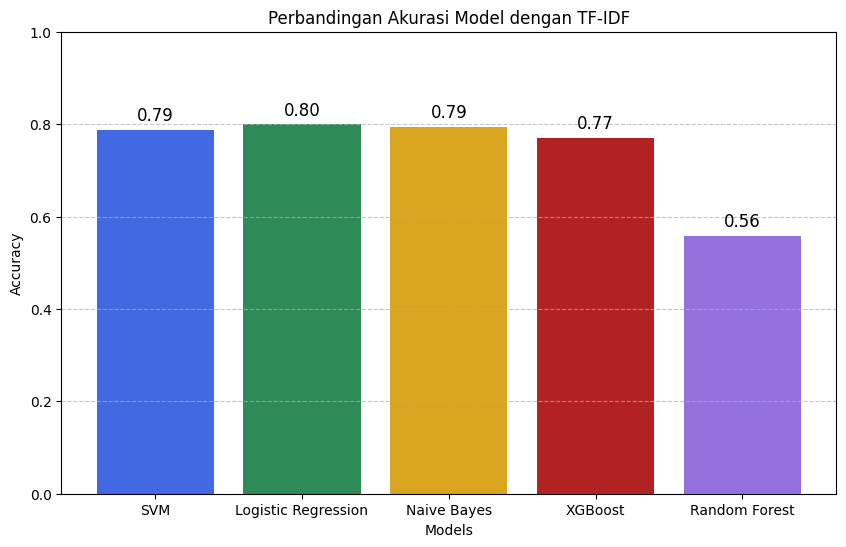

In [53]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['royalblue', 'seagreen', 'goldenrod', 'firebrick', 'mediumpurple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Model dengan TF-IDF")
plt.ylim(0.0, 1.0)  # Batas y-axis dari 0 hingga 1 (100%)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

plt.show()

# 2. Universal Sentence Encoder (USE)
1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

## Load the Universal Sentence Encoder model, and embed this model

In [54]:
start = timer()
use_embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for loading Universal Sentence Encoder (USE) from TensorFlow Hub:', timer() - start)


Required time for loading Universal Sentence Encoder (USE) from TensorFlow Hub: 19.853025634000005


In [55]:
xtrain_use = []
xtest_use = []

In [56]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_xtrain = xtrain[i:i + batch_size]
    batch_xtrain_use = np.array(use_embed(batch_xtrain))
    xtrain_use.extend(batch_xtrain_use)
print('Required time for embedding xtrain with Universal Sentence Encoder (USE):', timer() - start)

Required time for embedding xtrain with Universal Sentence Encoder (USE): 1.8468964660000893


In [57]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_xtest = xtest[i:i + batch_size]
    batch_xtest_use = np.array(use_embed(batch_xtest))
    xtest_use.extend(batch_xtest_use)
print('Required time for embedding xtest with Universal Sentence Encoder (USE):', timer() - start)

Required time for embedding xtest with Universal Sentence Encoder (USE): 0.3085769750000509


## Fit classifiers

In [58]:
start = timer()
svm_model_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier (USE):', timer() - start)

start = timer()
lr_model_use = logistic_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression (USE):', timer() - start)

start = timer()
xgboost_model_use = xgboost_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier (USE):', timer() - start)

start = timer()
rfc_model_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training Random Forest classifier (USE):', timer() - start)


Required time for training Linear SVM classifier (USE): 7.191920107000215
Required time for training Logistic Regression (USE): 4.092223837999882
Required time for training XGBoost classifier (USE): 67.53179490800017
Required time for training Random Forest classifier (USE): 8.334223143999907


## Linear SVM

In [59]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_model_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start)

Required time for Linear SVM prediction with USE :-  0.03550472200004151


### Print actual vs. predicted results for LinearSVM with USE

In [60]:
print("=== Hasil Prediksi SVM dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi SVM dengan USE Embedding ===
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 2, SVM with USE embedding Predicted: 2
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 2
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 0, SVM with USE embedding Predicted: 0
Actual: 2, SVM with USE embedding Predicted: 2



In [61]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("\nClassification Report:")
print(report_svm_use)
print("\nConfusion Matrix:")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.78
LinearSVM (USE) Precision: 0.74
LinearSVM (USE) Recall: 0.78
LinearSVM (USE) F1 score: 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.87      0.79      1310
           1       0.33      0.01      0.02       308
           2       0.83      0.85      0.84      1523

    accuracy                           0.78      3141
   macro avg       0.63      0.58      0.55      3141
weighted avg       0.74      0.78      0.74      3141


Confusion Matrix:
[[1140    2  168]
 [ 203    3  102]
 [ 221    4 1298]]


## Logitic Regression

In [62]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_model_use, xtest_use, ytest)
print('Required time for Logistic Regression prediction with USE :- ', timer() - start)

Required time for Logistic Regression prediction with USE :-  0.03276865300017562


### Print actual vs. predicted results for Logistic Regression with USE

In [63]:
print("=== Hasil Prediksi Logistic Regression dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi Logistic Regression dengan USE Embedding ===
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 2, Logistic Regression with USE embedding Predicted: 2
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 2
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 0, Logistic Regression with USE embedding Predicted: 0
Actual: 2, Logistic Regression with USE embedding Pred

In [64]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("\nClassification Report:")
print(report_lr_use)
print("\nConfusion Matrix:")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.78
Logistic Regression (USE) Precision: 0.73
Logistic Regression (USE) Recall: 0.78
Logistic Regression (USE) F1 score: 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.86      0.79      1310
           1       0.24      0.02      0.03       308
           2       0.83      0.86      0.84      1523

    accuracy                           0.78      3141
   macro avg       0.60      0.58      0.56      3141
weighted avg       0.73      0.78      0.74      3141


Confusion Matrix:
[[1132   10  168]
 [ 203    5  100]
 [ 213    6 1304]]


## XGBoost Classifier

In [65]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_model_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start)

Required time for XGBoost classifier prediction with USE:-  0.060806701000046814


### Print actual vs. predicted results for XGBooost classifier with USE

In [66]:
print("=== Hasil Prediksi XGBoost dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi XGBoost dengan USE Embedding ===
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 2, XGBoost with USE embedding Predicted: 2
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 2
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 0, XGBoost with USE embedding Predicted: 0
Actual: 2, XGBoost with USE embedding Predicted: 2



In [67]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("\nClassification Report:")
print(report_xgboost_use)
print("\nConfusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.77
XGBoost (USE) Precision: 0.72
XGBoost (USE) Recall: 0.77
XGBoost (USE) F1 score: 0.74

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.87      0.79      1310
           1       0.07      0.01      0.01       308
           2       0.84      0.84      0.84      1523

    accuracy                           0.77      3141
   macro avg       0.54      0.57      0.55      3141
weighted avg       0.72      0.77      0.74      3141


Confusion Matrix:
[[1144   15  151]
 [ 219    2   87]
 [ 228   11 1284]]


## Random Forest Classifier

In [68]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_model_use, xtest_use, ytest)
print('Required time for Random Forest classifier prediction with USE:- ', timer() - start)

Required time for Random Forest classifier prediction with USE:-  0.07495597299998735


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

### Print actual vs. predicted results for Random Forest classifier with USE

In [69]:
print("=== Hasil Prediksi Random Forest dengan USE Embedding ===")
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE embedding Predicted: {predicted}")
print()

=== Hasil Prediksi Random Forest dengan USE Embedding ===
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 2, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 2
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 0, Random Forest with USE embedding Predicted: 0
Actual: 2, Random Forest with USE embedding Predicted: 2



In [70]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("\nClassification Report:")
print(report_rfc_use)
print("\nConfusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.75
Random Forest (USE) Precision: 0.68
Random Forest (USE) Recall: 0.75
Random Forest (USE) F1 score: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.75      1310
           1       0.00      0.00      0.00       308
           2       0.80      0.84      0.82      1523

    accuracy                           0.75      3141
   macro avg       0.50      0.55      0.52      3141
weighted avg       0.68      0.75      0.71      3141


Confusion Matrix:
[[1072    0  238]
 [ 222    0   86]
 [ 247    0 1276]]


### Display all four models accuracy

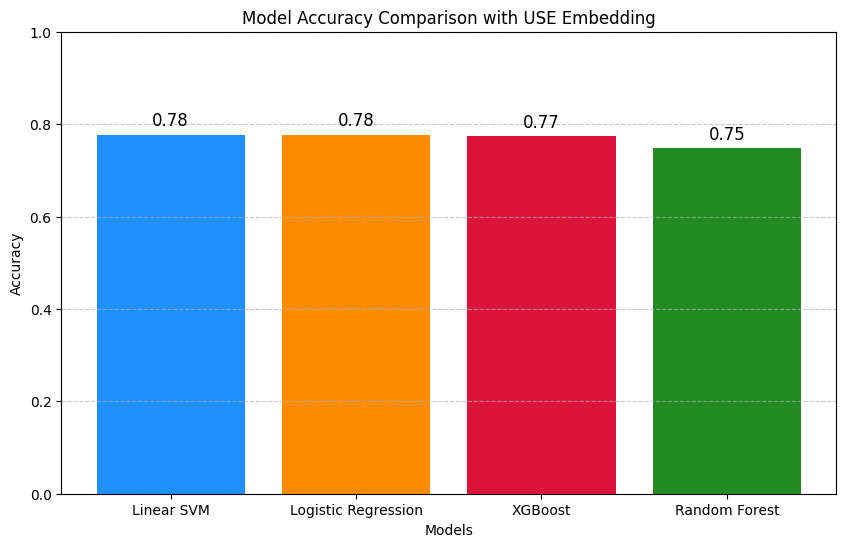

In [71]:
# List model names dan akurasi sesuai hasil evaluasi sebelumnya
model_names = ['Linear SVM', 'Logistic Regression', 'XGBoost', 'Random Forest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

# Membuat plot perbandingan akurasi model
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['dodgerblue', 'darkorange', 'crimson', 'forestgreen'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with USE Embedding")
plt.ylim(0.0, 1.0)  # Set batas y-axis dari 0 hingga 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan nilai akurasi pada setiap batang
for i, acc in enumerate(model_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', color='black', fontsize=12)

plt.show()


# 3. TF-IDF + Universal Sentence Encoder (USE)

1. Linear SVM
2. Logistic Regression
3. XGBoost classifier
4. Random Forest classifier

## Combine TF-IDF and Universal Sentence Encoder embeddings

In [72]:
# Menggabungkan TF-IDF dan USE untuk data training dan testing
xtrain_tfidf_use_combined = np.concatenate((tfidf_vectorizer_xtrain, xtrain_use), axis=1)
xtest_tfidf_use_combined = np.concatenate((tfidf_vectorizer_xtest, xtest_use), axis=1)

## Fit classifiers

In [73]:
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM (TF-IDF + USE):', timer() - start)

start = timer()
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression (TF-IDF + USE):', timer() - start)

start = timer()
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier (TF-IDF + USE):', timer() - start)

start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier (TF-IDF + USE):', timer() - start)


Required time for training Linear SVM (TF-IDF + USE): 8.861338448000197
Required time for training Logistic Regression (TF-IDF + USE): 23.175243766999984
Required time for training XGBoost classifier (TF-IDF + USE): 214.73608097600004
Required time for training Random Forest classifier (TF-IDF + USE): 6.062859260000096


## Linear SVM

In [74]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TF-IDF + USE:', timer() - start)

Required time for Linear SVM prediction with TF-IDF + USE: 0.11749510100003135


### Print actual vs. predicted results for Linear SVM with TFIDF + USE

In [75]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, Linear SVM (TF-IDF + USE) Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2

Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 0, Linear SVM (TF-IDF + USE) Predicted: 0

Actual: 2, Linear SVM (TF-IDF + USE) Predicted: 2



In [76]:
print(f"Linear SVM (TF-IDF + USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"Linear SVM (TF-IDF + USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix:")
print(cm_svm_tfidf_use)

Linear SVM (TF-IDF + USE) Accuracy: 0.79
Linear SVM (TF-IDF + USE) Precision: 0.76
Linear SVM (TF-IDF + USE) Recall: 0.79
Linear SVM (TF-IDF + USE) F1 score: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81      1310
           1       0.31      0.12      0.18       308
           2       0.85      0.86      0.85      1523

    accuracy                           0.79      3141
   macro avg       0.64      0.61      0.61      3141
weighted avg       0.76      0.79      0.77      3141

Confusion Matrix:
[[1123   48  139]
 [ 170   38  100]
 [ 180   35 1308]]


## Logistic Regression

In [77]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TF-IDF + USE:', timer() - start)

Required time for Logistic Regression prediction with TF-IDF + USE: 0.09089603699999316


### Print actual vs. predicted results for Logistic Regression with TFIDF + USE

In [78]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Actual: {actual}, Logistic Regression (TF-IDF + USE) Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 2, Logistic Regression (TF-IDF + USE) Predicted: 2

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 2, Logistic Regression (TF-IDF + USE) Predicted: 2

Actual: 2, Logistic Regression (TF-IDF + USE) Predicted: 2

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 0, Logistic Regression (TF-IDF + USE) Predicted: 0

Actual: 2, Logistic Regression (TF-IDF + USE) Predicted: 2



In [79]:
print(f"Logistic Regression (TF-IDF + USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TF-IDF + USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix:")
print(cm_lr_tfidf_use)

Logistic Regression (TF-IDF + USE) Accuracy: 0.80
Logistic Regression (TF-IDF + USE) Precision: 0.76
Logistic Regression (TF-IDF + USE) Recall: 0.80
Logistic Regression (TF-IDF + USE) F1 score: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1310
           1       0.26      0.06      0.09       308
           2       0.86      0.87      0.87      1523

    accuracy                           0.80      3141
   macro avg       0.63      0.61      0.59      3141
weighted avg       0.76      0.80      0.77      3141

Confusion Matrix:
[[1166   22  122]
 [ 195   17   96]
 [ 170   26 1327]]


## XGBoost Classifier

In [80]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TF-IDF + USE:', timer() - start)

Required time for XGBoost prediction with TF-IDF + USE: 0.15924690099996042


### Print actual vs. predicted results for XGBoost with TFIDF + USE

In [81]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Actual: {actual}, XGBoost (TF-IDF + USE) Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 2, XGBoost (TF-IDF + USE) Predicted: 2

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 2, XGBoost (TF-IDF + USE) Predicted: 2

Actual: 2, XGBoost (TF-IDF + USE) Predicted: 2

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 0, XGBoost (TF-IDF + USE) Predicted: 0

Actual: 2, XGBoost (TF-IDF + USE) Predicted: 2



In [86]:
print(f"XGBoost (TF-IDF + USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TF-IDF + USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TF-IDF + USE) Accuracy: 0.78
XGBoost (TF-IDF + USE) Precision: 0.74
XGBoost (TF-IDF + USE) Recall: 0.78
XGBoost (TF-IDF + USE) F1 score: 0.75
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.88      0.80      1310
           1       0.26      0.03      0.05       308
           2       0.85      0.85      0.85      1523

    accuracy                           0.78      3141
   macro avg       0.61      0.59      0.57      3141
weighted avg       0.74      0.78      0.75      3141

Confusion Matrix:
[[1152   11  147]
 [ 212    9   87]
 [ 218   14 1291]]


## Random Forest classifier

In [83]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TF-IDF + USE:', timer() - start)


Required time for Random Forest prediction with TF-IDF + USE: 0.09546747300009883


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

### Print actual vs. predicted results for Random Forest with TFIDF + USE

## Visualization

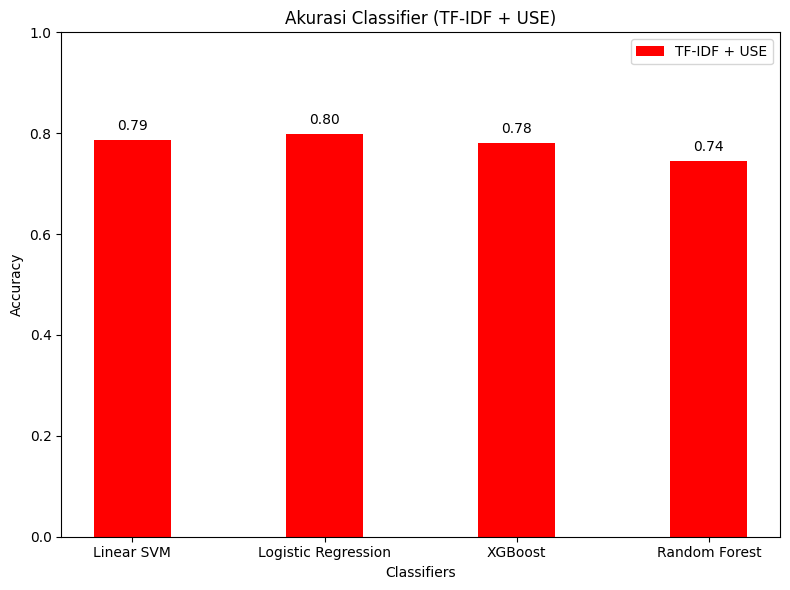

In [89]:
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]

x = np.arange(len(classifiers))
bar_width = 0.4

plt.figure(figsize=(8, 6))
plt.bar(x, tfidf_use_accuracies, width=bar_width, label='TF-IDF + USE', color='red')

plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Akurasi Classifier (TF-IDF + USE)')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Tampilkan nilai akurasi di atas bar
for i in range(len(classifiers)):
    plt.text(x[i], tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()
